In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cpu')
print("Environnement prêt !")
print(f"PyTorch version : {torch.__version__}")

Environnement prêt !
PyTorch version : 2.7.0+cpu


In [37]:
# Normalisation standard CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Téléchargement automatique (~170 Mo, une seule fois)
train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False)

CLASSES = ('avion','auto','oiseau','chat','cerf',
           'chien','grenouille','cheval','bateau','camion')

print(f"Train : {len(train_set)} images")
print(f"Test  : {len(test_set)} images")

Train : 50000 images
Test  : 10000 images


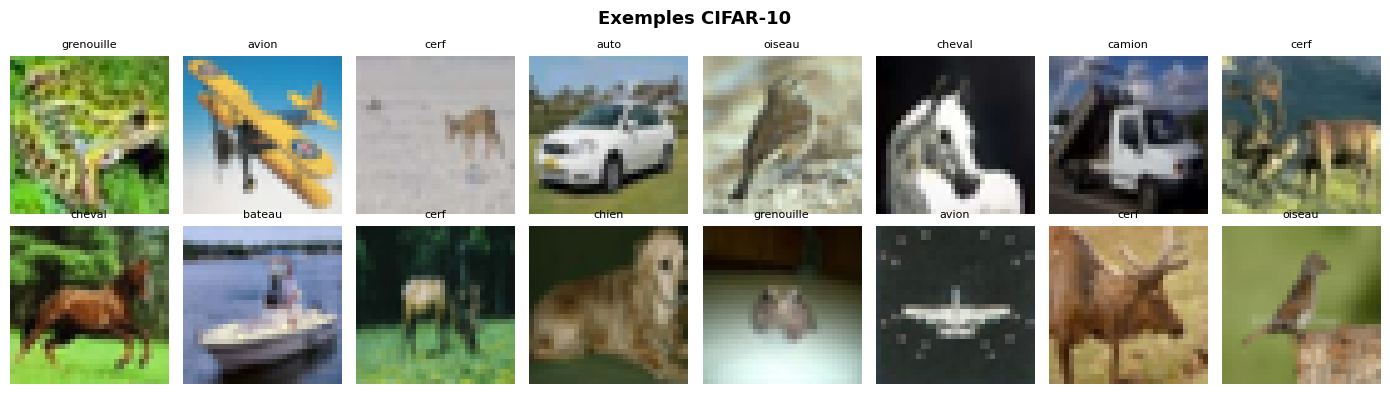

In [38]:
# Dénormalisation pour affichage
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

images, labels = next(iter(train_loader))  # un batch de 128

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')

plt.suptitle('Exemples CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dataset.png', dpi=150)
plt.show()

In [39]:
# Une seule couche de neurones
couche = nn.Linear(3072, 1024)
print(couche)
print(f"Poids : {couche.weight.shape}")
print(f"Biais : {couche.bias.shape}")

Linear(in_features=3072, out_features=1024, bias=True)
Poids : torch.Size([1024, 3072])
Biais : torch.Size([1024])


In [40]:
une_image = images[0]
print("Forme de l'image :", une_image.shape)

Forme de l'image : torch.Size([3, 32, 32])


## MLP

In [41]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.flatten(1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# On recrée le modèle, la loss et l'optimizer
mlp = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

print("Modèle prêt !")
print(mlp)

Modèle prêt !
MLP(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=10, bias=True)
)


In [42]:
mlp = MLP()
print(mlp)
print(f"\nNombre de paramètres : {sum(p.numel() for p in mlp.parameters()):,}")

MLP(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=10, bias=True)
)

Nombre de paramètres : 3,805,450


In [43]:
criterion = nn.CrossEntropyLoss()  # fonction de perte
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)  # optimiseur

print("Loss :", criterion)
print("Optimizer :", optimizer)

Loss : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [44]:
def entrainer(model, loader, criterion, optimizer):
    model.train()          # mode entraînement
    loss_totale = 0
    correct = 0
    total = 0

    for images, labels in loader:
        # 1. Prédiction
        predictions = model(images)

        # 2. Calcul de la loss
        loss = criterion(predictions, labels)

        # 3. On remet les gradients à zéro
        optimizer.zero_grad()

        # 4. Rétropropagation
        loss.backward()

        # 5. Mise à jour des poids
        optimizer.step()

        loss_totale += loss.item()
        correct += (predictions.argmax(1) == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    return loss_totale / len(loader), accuracy

In [45]:
def evaluer(model, loader, criterion):
    model.eval()           # mode évaluation
    loss_totale = 0
    correct = 0
    total = 0

    with torch.no_grad():  # on ne calcule pas les gradients
        for images, labels in loader:
            predictions = model(images)
            loss = criterion(predictions, labels)

            loss_totale += loss.item()
            correct += (predictions.argmax(1) == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return loss_totale / len(loader), accuracy

In [46]:
EPOQUES = 20
historique = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    # Entraînement
    train_loss, train_acc = entrainer(mlp, train_loader, criterion, optimizer)
    
    # Évaluation
    test_loss, test_acc = evaluer(mlp, test_loader, criterion)
    
    # Sauvegarde des résultats
    historique['train_loss'].append(train_loss)
    historique['train_acc'].append(train_acc)
    historique['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.669 | Train 0.405 | Test 0.462
Époque  2/20 | Loss 1.453 | Train 0.487 | Test 0.504
Époque  3/20 | Loss 1.343 | Train 0.525 | Test 0.513
Époque  4/20 | Loss 1.245 | Train 0.559 | Test 0.524
Époque  5/20 | Loss 1.163 | Train 0.585 | Test 0.529
Époque  6/20 | Loss 1.084 | Train 0.613 | Test 0.534
Époque  7/20 | Loss 1.013 | Train 0.637 | Test 0.532
Époque  8/20 | Loss 0.939 | Train 0.662 | Test 0.536
Époque  9/20 | Loss 0.884 | Train 0.684 | Test 0.540
Époque 10/20 | Loss 0.809 | Train 0.709 | Test 0.535
Époque 11/20 | Loss 0.751 | Train 0.729 | Test 0.538
Époque 12/20 | Loss 0.696 | Train 0.750 | Test 0.544
Époque 13/20 | Loss 0.652 | Train 0.765 | Test 0.536
Époque 14/20 | Loss 0.603 | Train 0.783 | Test 0.533
Époque 15/20 | Loss 0.558 | Train 0.801 | Test 0.527
Époque 16/20 | Loss 0.529 | Train 0.810 | Test 0.533
Époque 17/20 | Loss 0.493 | Train 0.822 | Test 0.535
Époque 18/20 | Loss 0.460 | Train 0.834 | Test 0.531
Époque 19/20 | Loss 0.446 | Train 0.840 | Test

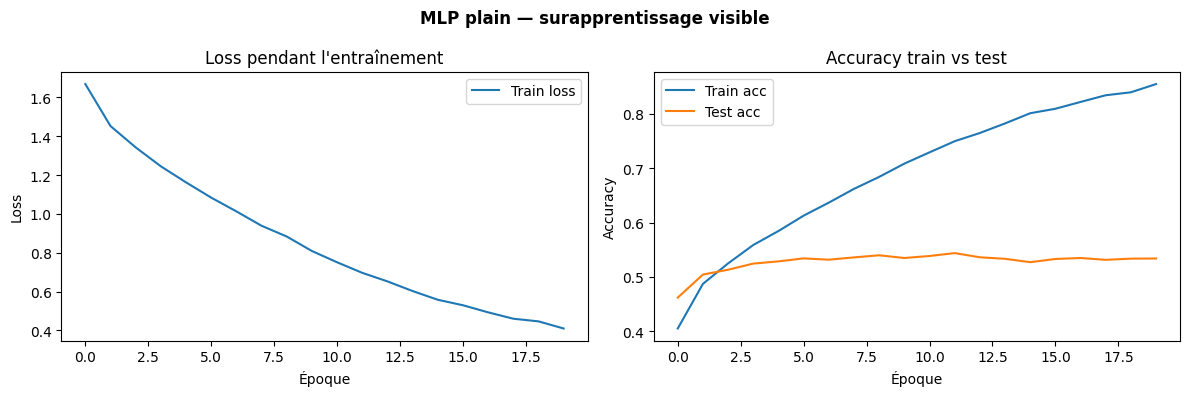

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe de loss
axes[0].plot(historique['train_loss'], label='Train loss')
axes[0].set_title('Loss pendant l\'entraînement')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Courbe d'accuracy
axes[1].plot(historique['train_acc'], label='Train acc')
axes[1].plot(historique['test_acc'],  label='Test acc')
axes[1].set_title('Accuracy train vs test')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('MLP plain — surapprentissage visible', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_mlp_plain.png', dpi=150)
plt.show()

Le MLP sans régularisation atteint une accuracy de 85.5% sur le train mais seulement 53.4% sur le test, soit un gap de 32.1 points. Ce surapprentissage massif s'explique par deux facteurs : le grand nombre de paramètres (3,8M) et l'absence de mécanisme de régularisation. La courbe de test stagne dès l'époque 5, indiquant que le réseau mémorise les données d'entraînement plutôt que d'apprendre des représentations généralisables

In [48]:
class MLP_Dropout(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x.flatten(1)
        x = self.drop(torch.relu(self.fc1(x)))
        x = self.drop(torch.relu(self.fc2(x)))
        x = self.drop(torch.relu(self.fc3(x)))
        x = self.fc4(x)
        return x

mlp_drop = MLP_Dropout(dropout=0.4)
criterion_drop = nn.CrossEntropyLoss()
optimizer_drop = torch.optim.Adam(mlp_drop.parameters(), lr=0.001)

print("MLP avec dropout prêt !")

MLP avec dropout prêt !


In [49]:
EPOQUES = 20
historique_drop = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoque in range(EPOQUES):
    train_loss, train_acc = entrainer(mlp_drop, train_loader, criterion_drop, optimizer_drop)
    test_loss, test_acc = evaluer(mlp_drop, test_loader, criterion_drop)
    
    historique_drop['train_loss'].append(train_loss)
    historique_drop['train_acc'].append(train_acc)
    historique_drop['test_acc'].append(test_acc)
    
    print(f"Époque {epoque+1:2d}/{EPOQUES} | "
          f"Loss {train_loss:.3f} | "
          f"Train {train_acc:.3f} | "
          f"Test {test_acc:.3f}")

Époque  1/20 | Loss 1.856 | Train 0.336 | Test 0.423
Époque  2/20 | Loss 1.705 | Train 0.395 | Test 0.443
Époque  3/20 | Loss 1.653 | Train 0.416 | Test 0.457
Époque  4/20 | Loss 1.620 | Train 0.428 | Test 0.463
Époque  5/20 | Loss 1.591 | Train 0.442 | Test 0.472
Époque  6/20 | Loss 1.570 | Train 0.450 | Test 0.450
Époque  7/20 | Loss 1.548 | Train 0.456 | Test 0.486
Époque  8/20 | Loss 1.531 | Train 0.463 | Test 0.493
Époque  9/20 | Loss 1.511 | Train 0.470 | Test 0.490
Époque 10/20 | Loss 1.501 | Train 0.472 | Test 0.488
Époque 11/20 | Loss 1.480 | Train 0.481 | Test 0.503
Époque 12/20 | Loss 1.468 | Train 0.483 | Test 0.491
Époque 13/20 | Loss 1.453 | Train 0.490 | Test 0.491
Époque 14/20 | Loss 1.440 | Train 0.497 | Test 0.504
Époque 15/20 | Loss 1.424 | Train 0.499 | Test 0.511
Époque 16/20 | Loss 1.413 | Train 0.503 | Test 0.504
Époque 17/20 | Loss 1.405 | Train 0.507 | Test 0.510
Époque 18/20 | Loss 1.390 | Train 0.517 | Test 0.505
Époque 19/20 | Loss 1.383 | Train 0.517 | Test

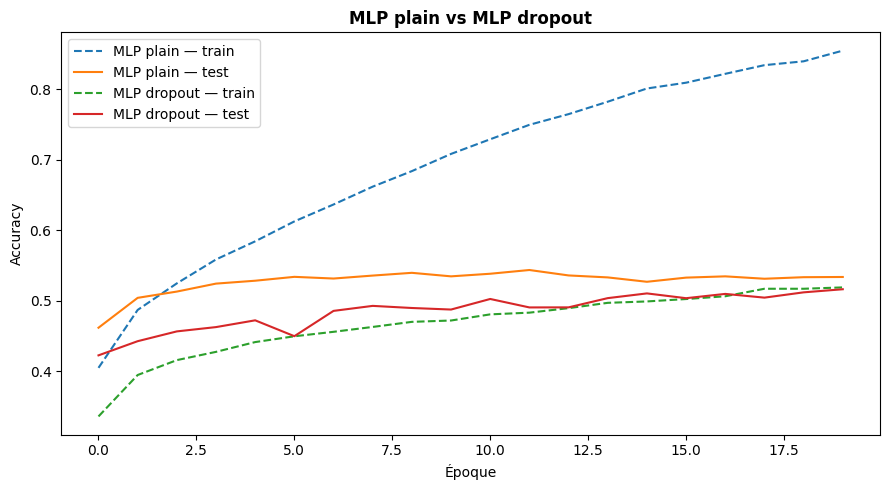

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(historique['train_acc'],      label='MLP plain — train', linestyle='--')
ax.plot(historique['test_acc'],       label='MLP plain — test')
ax.plot(historique_drop['train_acc'], label='MLP dropout — train', linestyle='--')
ax.plot(historique_drop['test_acc'],  label='MLP dropout — test')

ax.set_title('MLP plain vs MLP dropout', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig('fig_mlp_comparaison.png', dpi=150)
plt.show()

Le dropout (p=0.4) réduit drastiquement le surapprentissage : le gap train/test passe de 32.1 points à 0.3 points. Cependant, l'accuracy sur le test reste similaire (51.6% vs 53.4%), ce qui montre que la régularisation seule ne suffit pas à améliorer la généralisation du MLP. La limite est structurelle : en aplatissant l'image en un vecteur de 3072 valeurs, le MLP perd toute notion de proximité spatiale entre pixels. C'est cette limite fondamentale qui motive l'utilisation d'un CNN.